## In this notebook we use various training strategies to train our PNN on MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
sys.path.append('/home/anas/Desktop/Simulations/Training_NLO/nonlinear_oscillator_network/Utils')

from NN_utils import *
import torch
import torch.nn as nn
from torchvision import datasets, transforms
#from torchsummary import summary
import time
from types import SimpleNamespace
import pickle
import gc
from optimization_algorithms import *

In [2]:
transform_data = transforms.Compose([
    transforms.ToTensor()
    #transforms.Normalize((0.2868,), (0.3524,))
])

MNIST_train = datasets.MNIST(root='./data', train=True, transform=transform_data, download=True)
MNIST_test = datasets.MNIST(root='./data', train=False, transform=transform_data, download=True)

train_loader_MNIST = torch.utils.data.DataLoader(dataset=MNIST_train, batch_size=1000, shuffle=True)
test_loader_MNIST = torch.utils.data.DataLoader(dataset=MNIST_test, batch_size=10000, shuffle=False)

X_train_MNIST, Y_train_MNIST = next(iter(train_loader_MNIST))
X_test_MNIST, Y_test_MNIST = next(iter(test_loader_MNIST))

In [3]:

apply_PCA = False
number_PCs = 81

transform_data = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform_data, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform_data, download=True)

if apply_PCA:
    # Avoid giant DataLoader just to get arrays: use the raw tensors on the datasets
    X_train = (train_dataset.data.view(-1, 28*28).float() / 255.0).numpy()
    Y_train = train_dataset.targets.numpy()
    X_test  = (test_dataset.data.view(-1, 28*28).float() / 255.0).numpy()
    Y_test  = test_dataset.targets.numpy()

    # Fit PCA on train, transform train & test
    pca = PCA_analysis(X_train)
    X_train_pca = pca.transform(X_train, number_PCs)
    X_test_pca  = pca.transform(X_test,  number_PCs)

    # Wrap back into your Custom_dataset (expects numpy arrays)
    train_dataset = Custom_dataset(X_train_pca, Y_train)
    test_dataset  = Custom_dataset(X_test_pca,  Y_test)

# Now make normal loaders for training/eval (avoid workers inside Windows subprocess unless needed)
train_loader_MNIST = torch.utils.data.DataLoader(train_dataset, batch_size=1000, shuffle=True,  pin_memory=True, num_workers=0)
test_loader_MNIST  = torch.utils.data.DataLoader(test_dataset,  batch_size=10000, shuffle=False, pin_memory=True, num_workers=0)


In [7]:
N_neurons_vec = [5, 10, 20, 30, 50, 75, 100]
N_neurons_vec = [5]

n_epochs = 2
results = []

stats = 1

print("Script started at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

start_time = time.time()
for s in range(stats):
    for n_neurons in N_neurons_vec:
    #Initialize RNN
        input_dim = number_PCs if apply_PCA else 784
        RNN_params = {
            "N_in": input_dim,               # e.g., flattened 28x28 FashionMNIST image
            "N_out": 10,               # number of classes in FashionMNIST
            "N_neurons": n_neurons,          # number of hidden units per RNN layer
            "N_layers": 3             # depth of the RNN
        }
        
        model = Oscillator_RNN_parallel(params=RNN_params)
            
        model.init_esn_weights(reservoir = True)
        model.dt = 0.1
        model.eps_int = 1e-4
        model.alpha=3
        model.max_steps=40
        model.save_activations = False
        
        # for layer in model.W_in:
        #     for param in layer.parameters():
        #         param.requires_grad = False
                
        # model.W_input.weight.requires_grad = False
        # model.W_input.bias.requires_grad = False
        
        loss = nn.CrossEntropyLoss()
        
        
        N_dim = model.count_parameters()

        loss = nn.CrossEntropyLoss()
        # learning parameters
        
        init_pos = model.get_params()
        
        if init_pos.requires_grad:
            # Detach the tensor from the computation graph
            init_pos = init_pos.detach()
        if init_pos.is_cuda:
            # Move the tensor to the CPU
            init_pos = init_pos.cpu()
        init_pos = init_pos.numpy()
        
        pop_size = int(0.01*N_dim)

        CMA_optimizer = CMA_opt(N_dim, pop_size, select_pop=int(pop_size/2), sigma_init=0.1, mean_init=init_pos)
        #CMA_optimizer.eigen_update_frequency = N_dim // 10

                
        print(f'Using {n_neurons} per layer, run {s+1}, number of parameters {model.count_parameters()}')
        D = train_online_pop_parallel(model, n_epochs, train_loader_MNIST, test_loader_MNIST, loss, CMA_optimizer)
        results.append(D)
        
        del model
        del CMA_optimizer

        torch.cuda.empty_cache()
        gc.collect()
        
        
end_time = time.time()
print(f'Total time = {end_time- start_time} s')

Script started at: 2025-12-11 13:18:37
Using 5 per layer, run 1, number of parameters 4045
Using cuda device
Oscillator_RNN_parallel(
  (W_input): Linear(in_features=784, out_features=5, bias=True)
  (W_in): ModuleList(
    (0-1): 2 x Linear(in_features=5, out_features=5, bias=True)
  )
  (W_recurrent): ModuleList(
    (0-2): 3 x SparseLinear()
  )
  (W_out): Linear(in_features=5, out_features=10, bias=True)
)
NVIDIA GeForce RTX 3070 Laptop GPU
Epoch [1/2], Step [1/60], Loss: 2.333472163615772, Test Accuracy: 10.1%
Epoch [1/2], Step [10/60], Loss: 2.3133315737408835, Test Accuracy: 9.76%
Epoch [1/2], Step [20/60], Loss: 2.3131823871759805, Test Accuracy: 9.58%
Epoch [1/2], Step [30/60], Loss: 2.317426023805663, Test Accuracy: 9.58%
Epoch [1/2], Step [40/60], Loss: 2.3184189488713143, Test Accuracy: 10.28%
Epoch [1/2], Step [50/60], Loss: 2.3173074646080143, Test Accuracy: 11.35%
Epoch [1/2], Step [60/60], Loss: 2.312433414037611, Test Accuracy: 11.05%
Epoch [2/2], Step [1/60], Loss: 2.

In [9]:
1000*65/2/3600

9.027777777777779

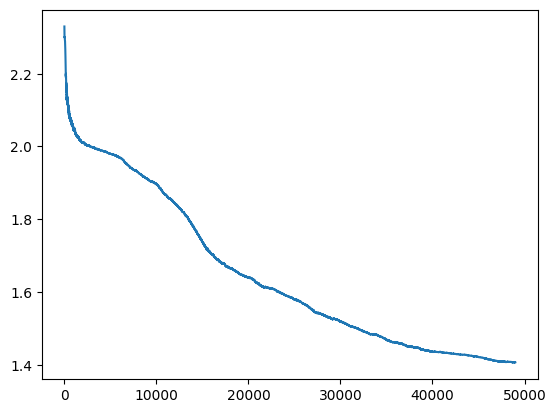

In [9]:
plt.plot(D['test_loss'])

In [15]:
np.arange(5)+1

array([1, 2, 3, 4, 5])

np.float64(0.0)

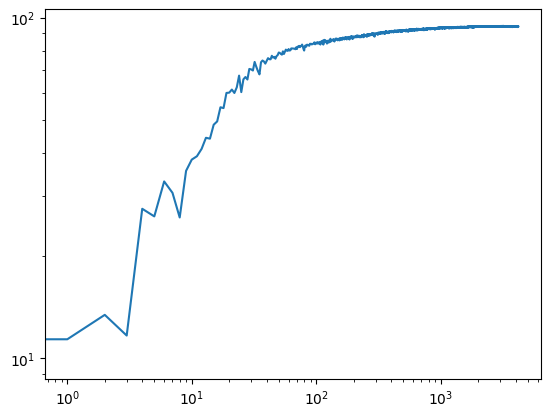

In [15]:
plt.loglog(D['test_acc'])

In [6]:
with open('results/PNN_PEPG_50neurons_MNIST.pkl', 'wb') as f:
    pickle.dump(results, f)     

In [ ]:
test_loss_vec = []
test_loss_std = []
test_acc_vec = []
test_acc_std = []
train_loss_vec = []
train_loss_std = []
n_params = []
idx_plot = -5  # average over the last 5 epochs

dummy = np.reshape(results, [stats, len(N_neurons_vec)])

for i in range(len(N_neurons_vec)):
    train_loss_runs = []
    test_loss_runs = []
    test_acc_runs = []
    
    for j in range(stats):
        train_loss = dummy[j, i]['train_loss']
        test_loss = dummy[j, i]['test_loss']
        test_acc = dummy[j, i]['test_acc']
        
        train_loss_runs.append(np.mean(train_loss[idx_plot:-1]))
        test_loss_runs.append(np.mean(test_loss[idx_plot:-1]))
        test_acc_runs.append(np.mean(test_acc[idx_plot:-1]))

    train_loss_vec.append(np.mean(train_loss_runs))
    test_loss_vec.append(np.mean(test_loss_runs))
    test_acc_vec.append(np.mean(test_acc_runs))

    train_loss_std.append(np.std(train_loss_runs))
    test_loss_std.append(np.std(test_loss_runs))
    test_acc_std.append(np.std(test_acc_runs))

    n_params.append(dummy[0, i]['n_params'])

n_params = np.array(n_params)

# Accuracy plot
plt.figure()
plt.loglog(n_params, test_acc_vec, '-o', label='Test Accuracy')
plt.fill_between(n_params,
                 np.array(test_acc_vec) - np.array(test_acc_std),
                 np.array(test_acc_vec) + np.array(test_acc_std),
                 alpha=0.3)
plt.xlabel('Number of parameters')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.loglog(n_params, test_loss_vec, '-o', label='Test Loss')
plt.fill_between(n_params,
                 np.array(test_loss_vec) - np.array(test_loss_std),
                 np.array(test_loss_vec) + np.array(test_loss_std),
                 alpha=0.3)

plt.loglog(n_params, train_loss_vec, '-o', label='Train Loss')
plt.fill_between(n_params,
                 np.array(train_loss_vec) - np.array(train_loss_std),
                 np.array(train_loss_vec) + np.array(train_loss_std),
                 alpha=0.3)

plt.xlabel('Number of parameters')
plt.ylabel('CCE Loss')
plt.grid(True)
plt.legend()
plt.show()